# Notebook 2 — Modélisation de la Maladie Cardiaque (Dataset Cardio)

Dans ce notebook, nous construisons et comparons trois modèles de classification :
- Régression Logistique (modèle simple)
- Random Forest (modèle intermédiaire)
- XGBoost(modèle avancé)

Les variables utilisées incluent notamment l'âge, le BMI, la tension,
le cholestérol, la glycémie, le tabagisme, l'alcool et l'activité physique.


## 1. Imports, chargement et préparation des données

In [45]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

%matplotlib inline

df = pd.read_csv('../data_clean/cardio_clean.csv')

# Features dérivées cohérentes avec le notebook EDA
df['age_years'] = (df['age'] / 365).round(1)
df['BMI'] = df['weight'] / ((df['height'] / 100) ** 2)

df.head()


,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,age_years,BMI
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0,50.4,21.967120
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1,55.4,34.927679
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1,51.7,23.507805
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1,48.3,28.710479
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0,47.9,23.011177


### Sélection des variables explicatives et de la cible

In [46]:

feature_cols = ['age_years', 'BMI', 'ap_hi', 'ap_lo',
                'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'gender']

X = df[feature_cols]
y = df['cardio']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train.shape, X_test.shape


((56000, 10), (14000, 10))

## 2. Modèle 1 — Régression Logistique

In [47]:

log_reg = LogisticRegression(max_iter=3000)
log_reg.fit(X_train_scaled, y_train)

y_pred_lr = log_reg.predict(X_test_scaled)

acc_lr = accuracy_score(y_test, y_pred_lr)
print("Accuracy Régression Logistique :", acc_lr)
print("\nRapport de classification :\n", classification_report(y_test, y_pred_lr))


Accuracy Régression Logistique : 0.7132142857142857

Rapport de classification :
               precision    recall  f1-score   support

           0       0.70      0.75      0.72      7004
           1       0.73      0.67      0.70      6996

    accuracy                           0.71     14000
   macro avg       0.71      0.71      0.71     14000
weighted avg       0.71      0.71      0.71     14000



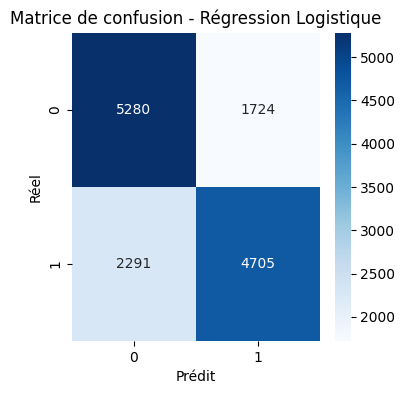

In [48]:

cm_lr = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(4,4))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues')
plt.title("Matrice de confusion - Régression Logistique")
plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.show()


## 3. Modèle 2 — Random Forest

In [49]:

rf = RandomForestClassifier(n_estimators=300, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

acc_rf = accuracy_score(y_test, y_pred_rf)
print("Accuracy Random Forest :", acc_rf)
print("\nRapport de classification :\n", classification_report(y_test, y_pred_rf))


Accuracy Random Forest : 0.707

Rapport de classification :
               precision    recall  f1-score   support

           0       0.71      0.71      0.71      7004
           1       0.71      0.71      0.71      6996

    accuracy                           0.71     14000
   macro avg       0.71      0.71      0.71     14000
weighted avg       0.71      0.71      0.71     14000



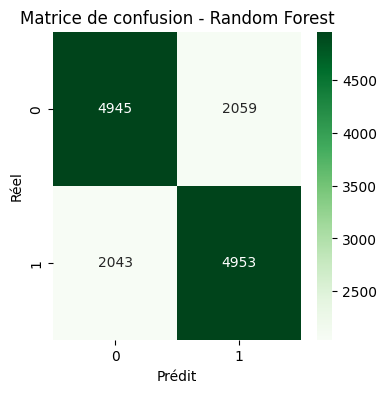

In [50]:

cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(4,4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens')
plt.title("Matrice de confusion - Random Forest")
plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.show()


## 4. Modèle 3 —  XGBoost

In [51]:

xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42
)

xgb.fit(X_train_scaled, y_train)
pred_xgb = xgb.predict(X_test_scaled)

acc_xgb = accuracy_score(y_test, pred_xgb)
acc_xgb


0.7326428571428572

In [52]:
print(classification_report(y_test, pred_xgb))

              precision    recall  f1-score   support

           0       0.72      0.77      0.74      7004
           1       0.75      0.70      0.72      6996

    accuracy                           0.73     14000
   macro avg       0.73      0.73      0.73     14000
weighted avg       0.73      0.73      0.73     14000



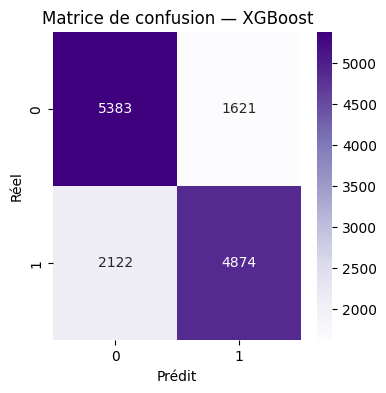

In [53]:
cm = confusion_matrix(y_test, pred_xgb)
plt.figure(figsize=(4,4))
sns.heatmap(cm, annot=True, fmt='d', cmap="Purples")
plt.title("Matrice de confusion — XGBoost")
plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.show()


## 5. Comparaison globale des modèles

In [54]:

results = {
    'LogisticRegression': acc_lr,
    'RandomForest': acc_rf,
    'XGBoost': acc_xgb
}
results


{'LogisticRegression': 0.7132142857142857,
 'RandomForest': 0.707,
 'XGBoost': 0.7326428571428572}

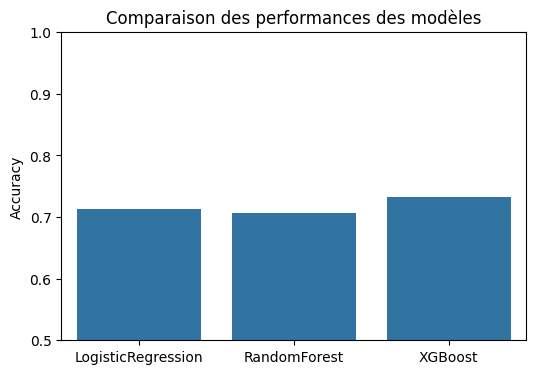

In [55]:

plt.figure(figsize=(6,4))
sns.barplot(x=list(results.keys()), y=list(results.values()))
plt.ylim(0.5, 1.0)
plt.ylabel("Accuracy")
plt.title("Comparaison des performances des modèles")
plt.show()


## 6. Sauvegarde du meilleur modèle pour le dashboard

Nous choisissons ici comme modèle final la **Random Forest**, que nous sauvegardons
avec le scaler dans des fichiers `model.pkl` et `scaler.pkl` utilisables par le dashboard Flask.


In [56]:

import pickle
import os

best_model = xgb  

base_dir = os.path.abspath('..')
model_path = os.path.join(base_dir, 'model.pkl')
scaler_path = os.path.join(base_dir, 'scaler.pkl')

with open(model_path, 'wb') as f:
    pickle.dump(best_model, f)

with open(scaler_path, 'wb') as f:
    pickle.dump(scaler, f)

model_path, scaler_path


('c:\\Users\\lenovo\\OneDrive\\Bureau\\projetfins1\\model.pkl',
 'c:\\Users\\lenovo\\OneDrive\\Bureau\\projetfins1\\scaler.pkl')